# Install Dependencies

In [ ]:
!git clone https://github.com/Stability-AI/stable-audio-tools.git

In [ ]:
!pip install stable-audio-tools

  Using cached stable_audio_tools-0.0.19-py3-none-any.whl.metadata (1.3 kB)
  Using cached alias_free_torch-0.0.6-py3-none-any.whl.metadata (3.8 kB)
  Using cached auraloss-0.4.0-py3-none-any.whl.metadata (8.0 kB)
  Using cached descript_audio_codec-1.0.0-py3-none-any.whl.metadata (7.8 kB)
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
  Using cached einops_exts-0.0.4-py3-none-any.whl.metadata (621 bytes)
  Using cached ema_pytorch-0.2.3-py3-none-any.whl.metadata (693 bytes)
  Using cached encodec-0.1.1.tar.gz (3.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached gradio-6.5.1-py3-none-any.whl.metadata (16 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached importlib_resources-5.12.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached k_diffusion-0.1.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached laion_clap-1.1.4-py3-none-any.wh

# Stable Audio Gradio Interface

In [64]:
!python3 ./stable-audio-tools/run_gradio.py --pretrained-name stabilityai/stable-audio-open-1.0

Loading pretrained model stabilityai/stable-audio-open-1.0
No module named 'flash_attn'
flash_attn not installed, disabling Flash Attention
/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|█| 99/99 [00:00<00:00, 5116.27it/s, Materializing param=sh
Done loading model
/Users/maurizioberta/Documents/Development/stable-audio-gen/stable-audio-tools/stable_audio_tools/interface/interfaces/diffusion_cond.py:521: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, js. Please pass these parameters to launch() instead.
  with gr.Blocks(js=js, theme=gr.themes.Base()) as ui:
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
^

# Import Libraries

In [1]:
import os
from transformers import AutoTokenizer
from stable_audio_tools import get_pretrained_model
import torch.nn.functional as F

/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Inference Scripts

In [65]:
import torch
import torchaudio
from einops import rearrange
from stable_audio_tools import get_pretrained_model
from stable_audio_tools.inference.generation import generate_diffusion_cond
import json
import os
import re
from datetime import datetime

device = "cuda" if torch.cuda.is_available() else "mps"

# Download model
model, model_config = get_pretrained_model("stabilityai/stable-audio-open-1.0")
sample_rate = model_config["sample_rate"]
sample_size = model_config["sample_size"]
model = model.to(device)

/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 99/99 [00:00<00:00, 2577.52it/s, Materializing param=shared.weight]                                                     


In [66]:
def run_inference(prompt_ls = []):
    # Create output directory
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    #script_dir = os.path.dirname(os.path.abspath(__file__))
    script_dir = os.getcwd()
    output_dir = os.path.join(script_dir, f"run_{run_id}")
    os.makedirs(output_dir, exist_ok=True)

    # Generation params
    params = {
        "run_id": run_id,
        "model": "stabilityai/stable-audio-open-1.0",
        "prompt_list": prompt_ls,
        "seconds_start": 0,
        "seconds_total": 30,
        "steps": 100,
        "cfg_scale": 7,
        "sigma_min": 0.3,
        "sigma_max": 500,
        "sampler_type": "dpmpp-3m-sde",
        "device": device,
        "sample_rate": sample_rate,
        "sample_size": sample_size
    }

    with open(os.path.join(output_dir, "params.json"), "w") as f:
        json.dump(params, f, indent=2)

    for prompt in params["prompt_list"]:
        # Set up text and timing conditioning
        conditioning = [{
            "prompt": prompt,
            "seconds_start": 0,
            "seconds_total": 30
        }]

        # Generate stereo audio
        output = generate_diffusion_cond(
            model,
            steps=100,
            cfg_scale=7,
            conditioning=conditioning,
            sample_size=sample_size,
            sigma_min=0.3,
            sigma_max=500,
            sampler_type="dpmpp-3m-sde",
            device=device
        )

        # Rearrange audio batch to a single sequence
        output = rearrange(output, "b d n -> d (b n)")

        # Peak normalize, clip, convert to int16, and save to file
        output = output.to(torch.float32).div(torch.max(torch.abs(output))).clamp(-1, 1).mul(32767).to(torch.int16).cpu()
        filename = re.sub(r'[^a-z0-9]+', '_', prompt.lower()).strip('_') + '.wav'
        torchaudio.save(os.path.join(output_dir, filename), output, sample_rate)

    print(f"Saved to {output_dir}")

# Exploring the tokenization

I'm exploring how prompt are translated into tokens, trying to see how the length in tokens differs in various cases.

In [2]:
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")

prompt_ls = ["traffic","traffic traffic car horn", "TRAFFIC"]
for prompt in prompt_ls:
    tokens = tokenizer(prompt)
    print(len(tokens["input_ids"]))  # compare against the 128 limit

2
6
5


First, finding the all caps uses 3 more tokens than the lowercase, making it effectively more important.

In [3]:
prompt_ls = ["traffic traffic traffic traffic", "TRAFFIC"]
for prompt in prompt_ls:
    tokens = tokenizer(prompt)
    print(len(tokens["input_ids"]), tokens)  # compare against the 128 limit

5 {'input_ids': [2117, 2117, 2117, 2117, 1], 'attention_mask': [1, 1, 1, 1, 1]}
5 {'input_ids': [3, 11359, 9089, 4666, 1], 'attention_mask': [1, 1, 1, 1, 1]}


Also their tokens are quite different

Now I try to get the embedding so that I can later calculate the similarity of embeddings.

In [55]:
config = get_pretrained_model("stabilityai/stable-audio-open-1.0")
conditioner = model.conditioner.conditioners["prompt"]  # the T5Conditioner

# Access the underlying T5 model
t5_model = conditioner.model  # This is the actual T5EncoderModel

def get_exact_embeddings_with_attention(prompt, device="mps"):
    # Tokenize using the conditioner's tokenizer
    tokens = conditioner.tokenizer(
        prompt,
        padding="max_length",
        max_length=conditioner.max_length,
        truncation=True,
        return_tensors="pt"
    ).to(device)
    
    # Get outputs with attention
    outputs = t5_model(
        input_ids=tokens["input_ids"],
        attention_mask=tokens["attention_mask"],
        output_attentions=True
    )
    
    # Get embeddings and attention
    embeds = outputs.last_hidden_state  # [1, 128, 768]
    attentions = outputs.attentions     # Tuple of attention tensors, one per layer
    mask = tokens["attention_mask"]     # [1, 128]
    
    return embeds, mask, attentions

# Example usage
prompt_ls = ["traffic", "traffic traffic car horn", "TRAFFIC"]

for prompt in prompt_ls:
    embeds, mask, attentions = get_exact_embeddings_with_attention(prompt)
    
    print(f"\nPrompt: '{prompt}'")
    print(f"Embedding shape: {embeds.shape}")
    print(f"Number of attention layers: {len(attentions)}")
    print(f"Attention shape (layer 0): {attentions[0].shape}")
    # Shape: (batch_size, num_heads, seq_length, seq_length)
    
    # You can still use masked mean
    pooled = masked_mean(embeds, mask)
    print(f"Pooled shape: {pooled.shape}")

# Mean-pool over real tokens only
def masked_mean(emb, mask):
    mask = mask.unsqueeze(-1).float()
    return (emb * mask).sum(1) / mask.sum(1)  # [1, 768]

/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 99/99 [00:00<00:00, 1044.02it/s, Materializing param=shared.weight]                                                     



Prompt: 'traffic'
Embedding shape: torch.Size([1, 128, 768])
Number of attention layers: 12
Attention shape (layer 0): torch.Size([1, 12, 128, 128])
Pooled shape: torch.Size([1, 768])

Prompt: 'traffic traffic car horn'
Embedding shape: torch.Size([1, 128, 768])
Number of attention layers: 12
Attention shape (layer 0): torch.Size([1, 12, 128, 128])
Pooled shape: torch.Size([1, 768])

Prompt: 'TRAFFIC'
Embedding shape: torch.Size([1, 128, 768])
Number of attention layers: 12
Attention shape (layer 0): torch.Size([1, 12, 128, 128])
Pooled shape: torch.Size([1, 768])


In [57]:
def interpret_attention(prompt, layer_idx=0, head_idx=0):
    embeds, mask, attentions = get_exact_embeddings_with_attention(prompt)
    
    # Get tokens
    tokens = conditioner.tokenizer.tokenize(prompt)
    token_ids = conditioner.tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    token_texts = [conditioner.tokenizer.decode([tid]) for tid in token_ids]
    
    # Get attention for specific layer and head
    attn = attentions[layer_idx][0, head_idx]  # [128, 128]
    
    # Focus on real tokens (not padding)
    real_length = mask[0].sum().item()
    attn = attn[:real_length, :real_length]  # Trim to real tokens
    
    print(f"\nPrompt: '{prompt}'")
    print(f"Tokens: {token_texts[:real_length]}")
    print(f"\nAttention matrix shape: {attn.shape}")
    
    # Show what token 0 attends to
    print(f"\nToken 0 ('{token_texts[0]}') attention distribution:")
    for i, weight in enumerate(attn[0]):
        if i < real_length:
            print(f"  -> Token {i} ('{token_texts[i]}'): {weight:.3f}")
    
    return attn, token_texts[:real_length]

# Example
attn, tokens = interpret_attention("traffic traffic car horn", layer_idx=0, head_idx=0)


Prompt: 'traffic traffic car horn'
Tokens: ['traffic', 'traffic', 'car', '', 'horn', '</s>']

Attention matrix shape: torch.Size([6, 6])

Token 0 ('traffic') attention distribution:
  -> Token 0 ('traffic'): 0.820
  -> Token 1 ('traffic'): 0.168
  -> Token 2 ('car'): 0.007
  -> Token 3 (''): 0.004
  -> Token 4 ('horn'): 0.000
  -> Token 5 ('</s>'): 0.000


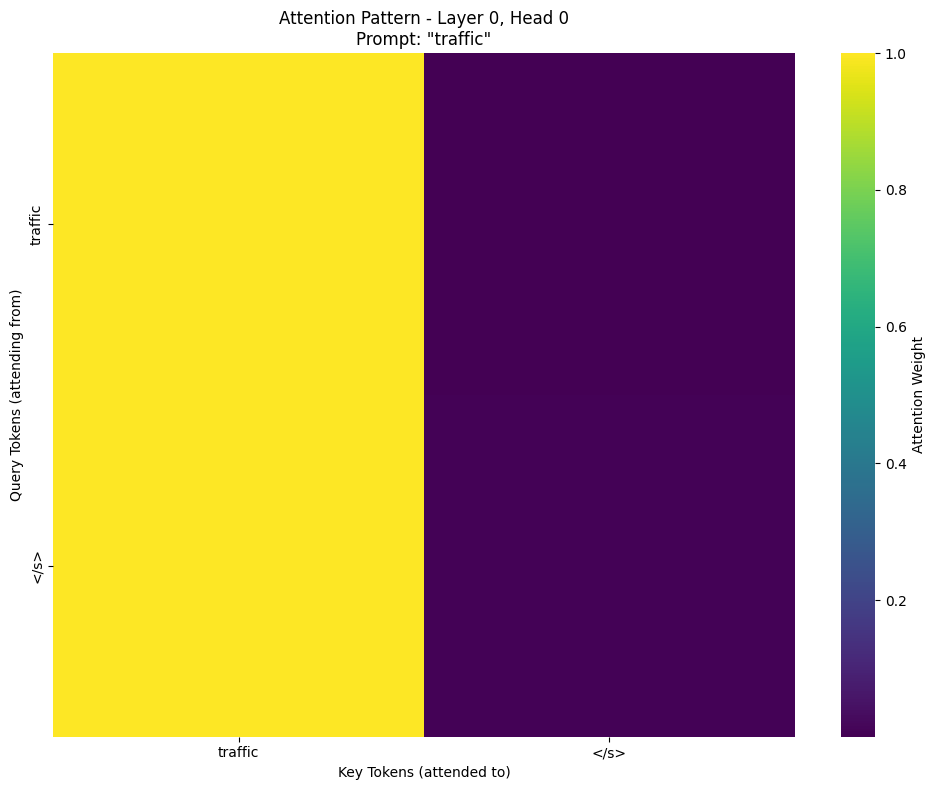

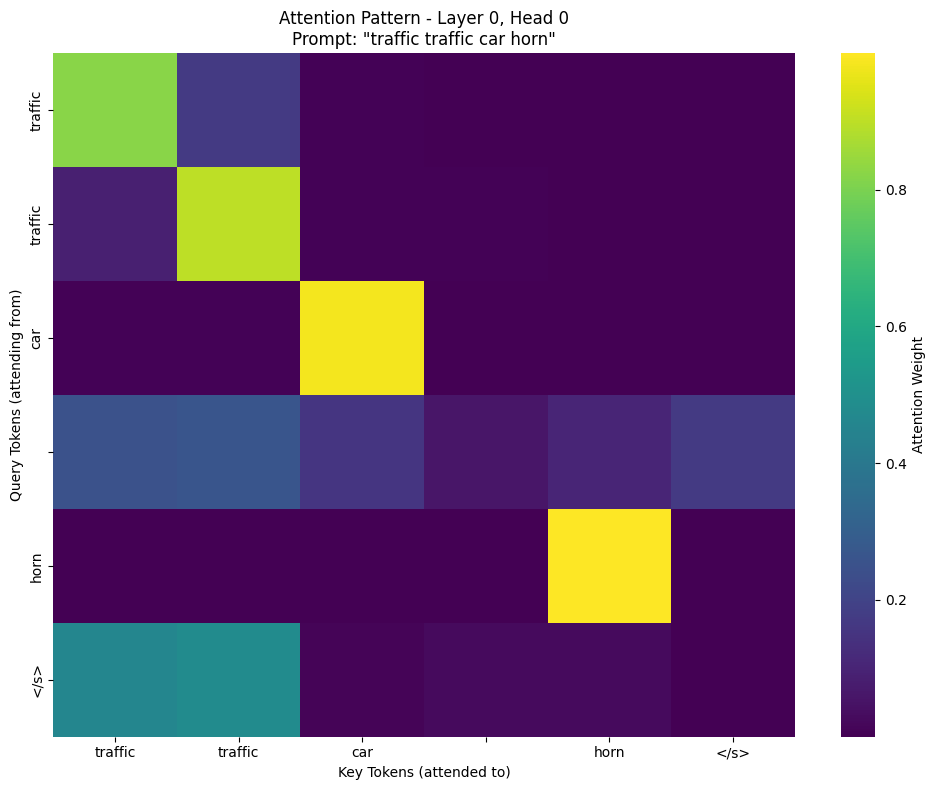

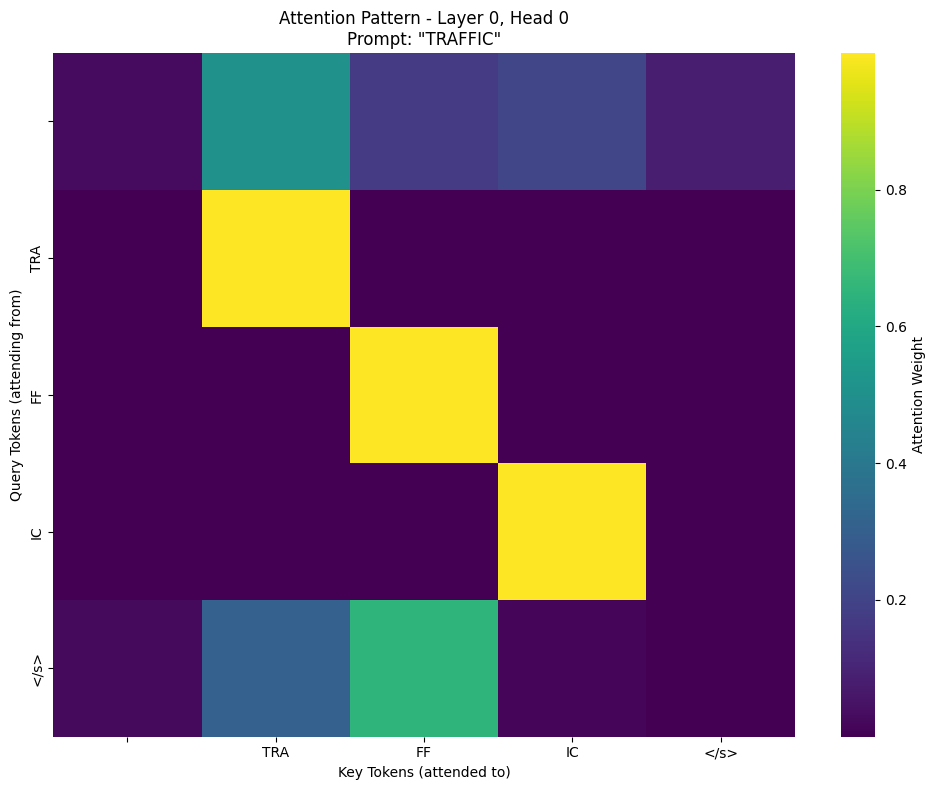

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_attention(prompt, layer_idx=0, head_idx=0):
    embeds, mask, attentions = get_exact_embeddings_with_attention(prompt)
    
    # Get tokens
    token_ids = conditioner.tokenizer(prompt, return_tensors="pt")["input_ids"][0]
    token_texts = [conditioner.tokenizer.decode([tid]) for tid in token_ids]
    
    # Get attention and trim to real tokens
    real_length = mask[0].sum().item()
    attn = attentions[layer_idx][0, head_idx, :real_length, :real_length]
    tokens = token_texts[:real_length]
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(attn.cpu().numpy(), 
                xticklabels=tokens, 
                yticklabels=tokens,
                cmap='viridis',
                cbar_kws={'label': 'Attention Weight'})
    plt.xlabel('Key Tokens (attended to)')
    plt.ylabel('Query Tokens (attending from)')
    plt.title(f'Attention Pattern - Layer {layer_idx}, Head {head_idx}\nPrompt: "{prompt}"')
    plt.tight_layout()
    plt.show()

# Visualize different prompts
for prompt in ["traffic", "traffic traffic car horn", "TRAFFIC"]:
    visualize_attention(prompt, layer_idx=0, head_idx=0)

In [62]:
import torch

def analyze_attention_patterns(prompt):
    embeds, mask, attentions = get_exact_embeddings_with_attention(prompt)
    real_length = mask[0].sum().item()
    
    print(f"\nAnalyzing: '{prompt}'")
    
    # Average across all heads and layers
    all_attn = torch.stack([attn[0, :, :real_length, :real_length] 
                            for attn in attentions])  # [layers, heads, seq, seq]
    avg_attn = all_attn.mean(dim=[0, 1])  # [seq, seq]
    
    # 1. Self-attention: diagonal values
    self_attn = avg_attn.diagonal()
    print(f"Self-attention (tokens attending to themselves): {self_attn.mean():.3f}")
    
    # 2. Which token gets most attention overall?
    total_attn_received = avg_attn.sum(dim=0)  # Sum over all query tokens
    most_attended_idx = total_attn_received.argmax()
    tokens = [conditioner.tokenizer.decode([tid]) for tid in 
              conditioner.tokenizer(prompt, return_tensors="pt")["input_ids"][0][:real_length]]
    print(f"Most attended token: '{tokens[most_attended_idx]}' (index {most_attended_idx})")
    
    # 3. Compare duplicate words (e.g., "traffic" vs "traffic")
    if "traffic traffic" in prompt.lower():
        print("\nComparing duplicate words:")
        print(f"First 'traffic' -> Second 'traffic': {avg_attn[0, 1]:.3f}")
        print(f"Second 'traffic' -> First 'traffic': {avg_attn[1, 0]:.3f}")

# Test
for prompt in prompt_ls:
    analyze_attention_patterns(prompt)


Analyzing: 'traffic'
Self-attention (tokens attending to themselves): 0.390
Most attended token: '</s>' (index 1)

Analyzing: 'traffic traffic car horn'
Self-attention (tokens attending to themselves): 0.155
Most attended token: '</s>' (index 5)

Comparing duplicate words:
First 'traffic' -> Second 'traffic': 0.137
Second 'traffic' -> First 'traffic': 0.165

Analyzing: 'TRAFFIC'
Self-attention (tokens attending to themselves): 0.168
Most attended token: '</s>' (index 4)


In [63]:
def compare_layers(prompt):
    embeds, mask, attentions = get_exact_embeddings_with_attention(prompt)
    real_length = mask[0].sum().item()
    
    print(f"\nPrompt: '{prompt}'")
    
    # Early vs late layers
    early_attn = attentions[0][0, :, :real_length, :real_length].mean(0)  # Avg across heads
    late_attn = attentions[-1][0, :, :real_length, :real_length].mean(0)
    
    print(f"Early layer (0) attention entropy: {-torch.sum(early_attn * torch.log(early_attn + 1e-9), dim=-1).mean():.3f}")
    print(f"Late layer (-1) attention entropy: {-torch.sum(late_attn * torch.log(late_attn + 1e-9), dim=-1).mean():.3f}")
    print("(Lower entropy = more focused attention)")

compare_layers("traffic traffic car horn")


Prompt: 'traffic traffic car horn'
Early layer (0) attention entropy: 1.555
Late layer (-1) attention entropy: 0.975
(Lower entropy = more focused attention)


In [5]:
model, config = get_pretrained_model("stabilityai/stable-audio-open-1.0")
conditioner = model.conditioner.conditioners["prompt"]  # the T5Conditioner

def get_exact_embeddings(prompt, device="mps"):
    embeds, mask = conditioner([prompt], device=device)
    # embeds: [1, 128, 768] — exactly what cross-attention sees
    # mask: [1, 128] — 1 for real tokens, 0 for padding
    return embeds, mask

# Mean-pool over real tokens only
def masked_mean(emb, mask):
    mask = mask.unsqueeze(-1).float()
    return (emb * mask).sum(1) / mask.sum(1)  # [1, 768]

/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 99/99 [00:00<00:00, 2066.90it/s, Materializing param=shared.weight]                                                     


In [6]:
e1, m1 = get_exact_embeddings("TRAFFIC")
e2, m2 = get_exact_embeddings("traffic traffic traffic traffic traffic traffic traffic traffic traffic traffic traffic")

sim = F.cosine_similarity(masked_mean(e1, m1), masked_mean(e2, m2))
print(f"Similarity: {sim.item():.3f}")

/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/stable_audio_tools/models/conditioners.py:362: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16) and torch.set_grad_enabled(self.enable_grad):
/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Similarity: 0.305


## Interpolation between strings

In [9]:
import argparse, re

def interpolate(start, end, steps):
    interp_ls = []
    a, b = start.split(), end.split()
    for i in range(steps):
        t = i / (steps - 1)
        na = round(len(a) * (1 - t))
        nb = round(len(b) * t)
        interp_ls.append(" ".join(a[:na] + b[len(b)-nb:] if nb else a[:na]))
        #print(f"[{t:.2f}] " + " ".join(a[:na] + b[len(b)-nb:] if nb else a[:na]))
    return interp_ls

In [34]:
contrasting_prompt_env = ["traffic car horns city", "nature birds chirping forest"]
contrasting_prompt_music_env = ["grand-piano C4", "traffic car horns city"]
contrasting_prompt_music = ["grand-piano C4", "cello solo melody ascending"]
count_tokens(contrasting_prompt_music)


Token count per prompt: 
Prompt:  grand-piano C4 –– Number of tokens:  7 –– Tokens:  [1907, 18, 21851, 32, 205, 591, 1]
Prompt:  cello solo melody ascending –– Number of tokens:  7 –– Tokens:  [2358, 32, 6729, 27832, 25200, 53, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


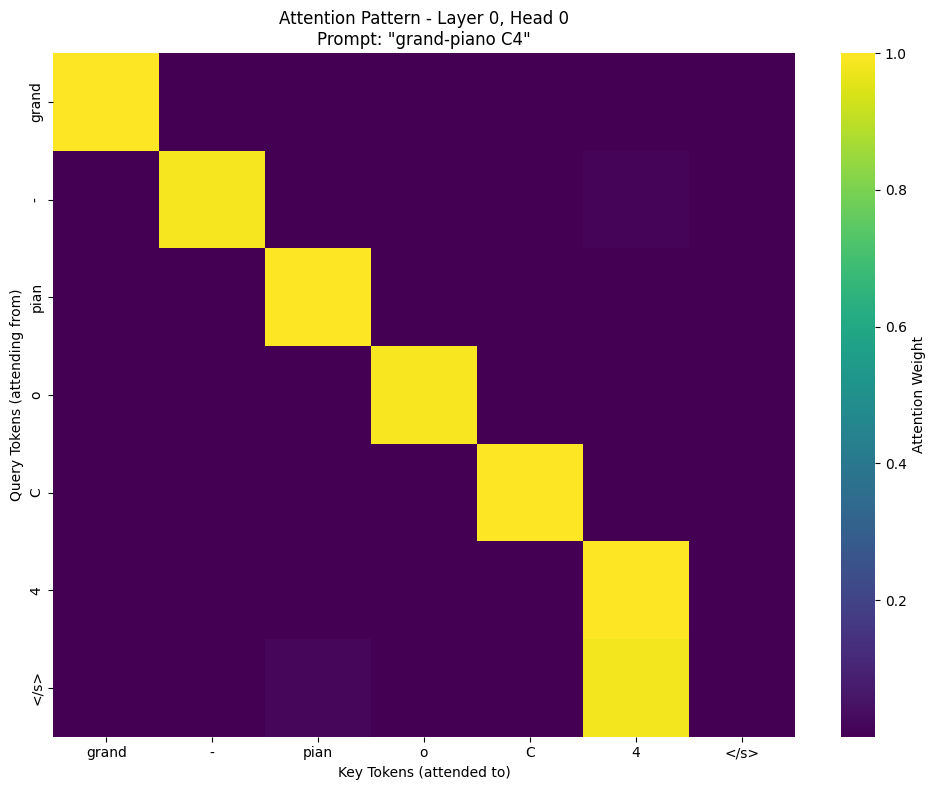

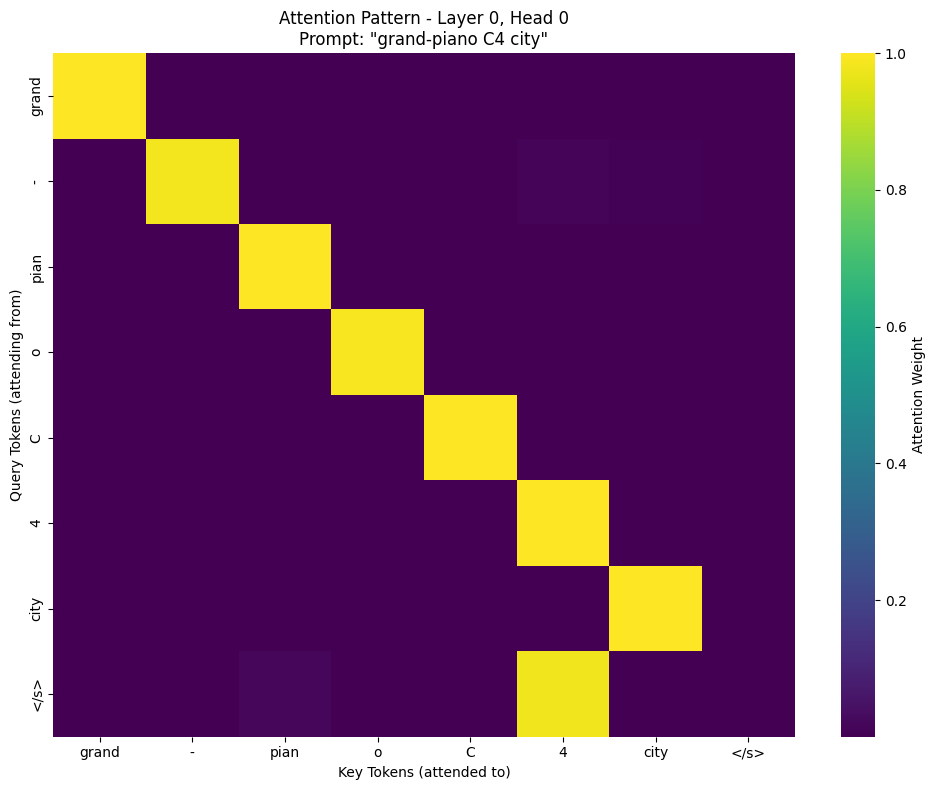

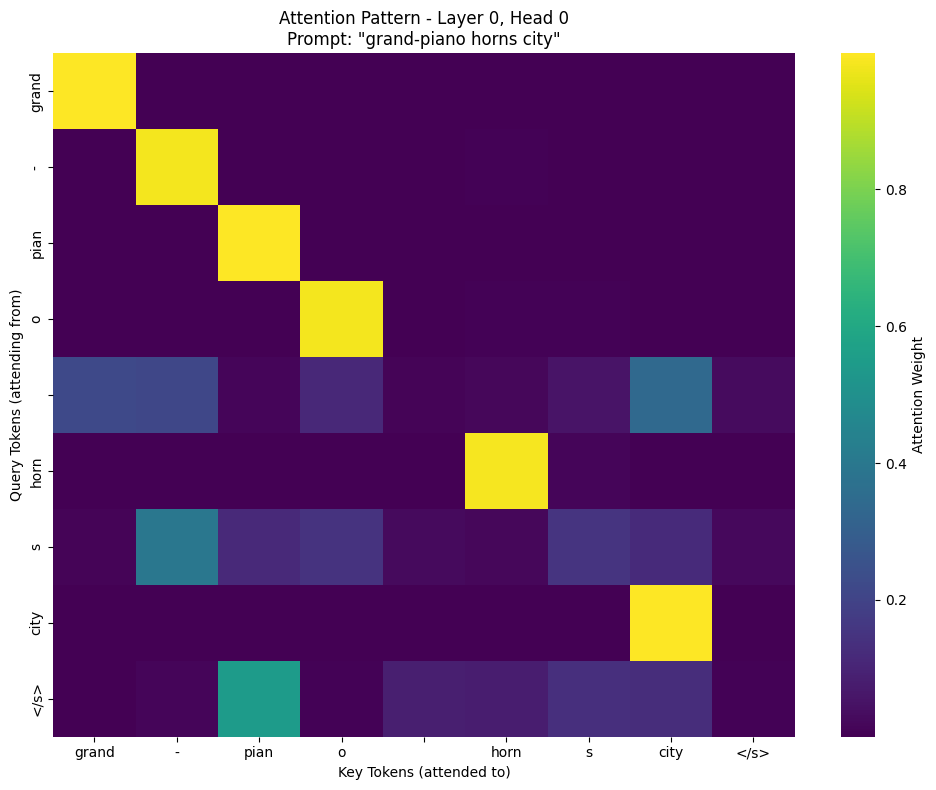

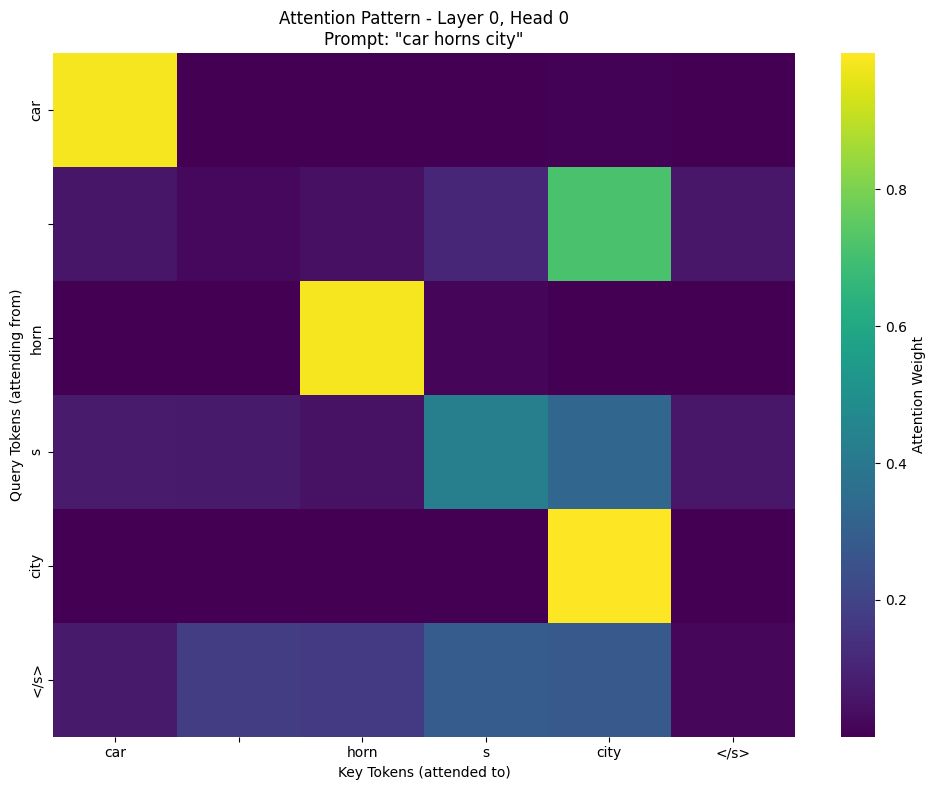

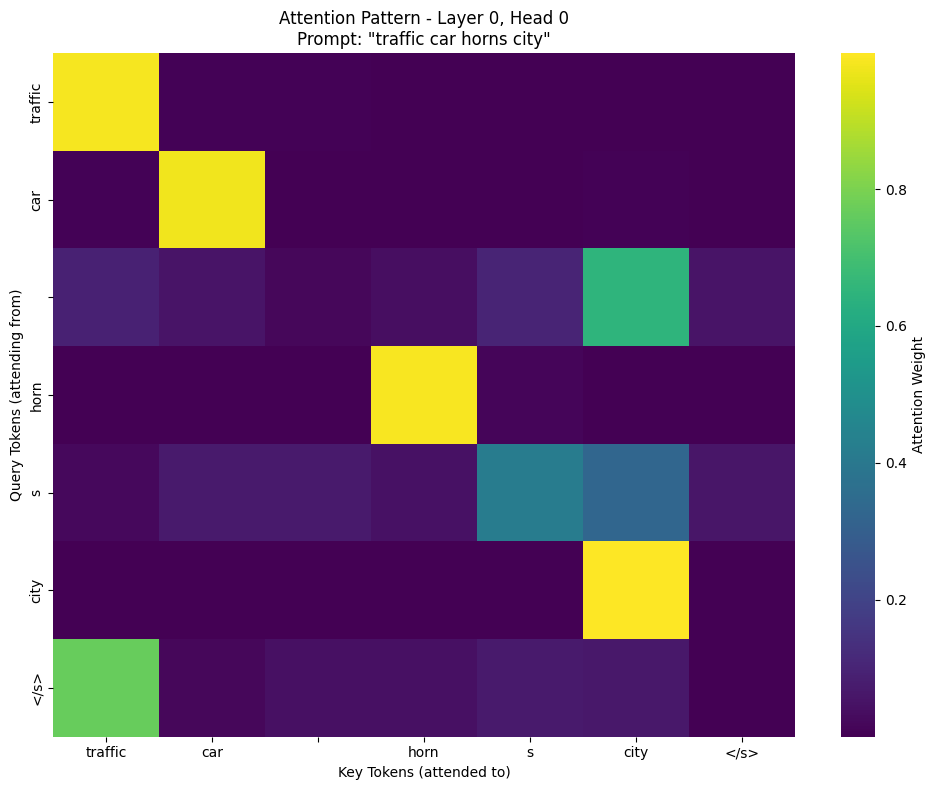

In [70]:
# Visualize different prompts
for prompt in interp_ls:
    visualize_attention(prompt, layer_idx=0, head_idx=0)

In [ ]:
paired_similarity(contrasting_prompt_music)

Prompt:  grand-piano C4  |  cello solo melody ascending –––– Similarity: 0.618
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


In [47]:
interp_ls

['traffic car horns city',
 'traffic car horns forest',
 'traffic car chirping forest',
 'traffic birds chirping forest',
 'nature birds chirping forest']

In [ ]:
run_inference(interp_ls)

In [72]:
#contrasting_prompt_env 
#contrasting_prompt_music_env 
#contrasting_prompt_music 
#0 - 1
print("Direction frontal: ")
interp_ls = interpolate(contrasting_prompt_env[0], contrasting_prompt_env[1], 5)
for el in interp_ls:
    count_tokens([el])
run_inference(interp_ls)
#1 - 0
print("Direction inverted: ")
interp_ls = interpolate(contrasting_prompt_env[1], contrasting_prompt_env[0], 5)
for el in interp_ls:
    count_tokens([el])
run_inference(interp_ls)

Direction frontal: 
Token count per prompt: 
Prompt:  traffic car horns city –– Number of tokens:  7 –– Tokens:  [2117, 443, 3, 6293, 7, 690, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  traffic car horns forest –– Number of tokens:  7 –– Tokens:  [2117, 443, 3, 6293, 7, 5827, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  traffic car chirping forest –– Number of tokens:  7 –– Tokens:  [2117, 443, 3, 11727, 2462, 5827, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  traffic birds chirping forest –– Number of tokens:  7 –– Tokens:  [2117, 6331, 3, 11727, 2462, 5827, 1]
–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/stable_audio_tools/models/conditioners.py:362: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16) and torch.set_grad_enabled(self.enable_grad):
/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
  0%|          | 0/100 [00:00<?, ?it/s]/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:608: UserWarning: Should have tb<=t1 but got tb=500.00006103515625 and t1=500.000061.
  warnings.warn(f"Should have {tb_name}<=t1 but got {tb_name}={tb} and t1={self._end}.")
 98%|█████████▊| 98/100 [01:40<00:02,  1.02s/it]/Users/ma

116760462


100%|██████████| 100/100 [01:43<00:00,  1.04s/it]


2739858652


...

3625517360


100%|██████████| 100/100 [01:48<00:00,  1.08s/it]


1702567913


100%|██████████| 100/100 [01:48<00:00,  1.09s/it]


Saved to /Users/maurizioberta/Documents/Development/stable-audio-gen/run_20260301_200305


In [73]:
#contrasting_prompt_music_env 

#0 - 1
print("Direction frontal: ")
interp_ls = interpolate(contrasting_prompt_music_env[0], contrasting_prompt_music_env[1], 5)
for el in interp_ls:
    count_tokens([el])
run_inference(interp_ls)
#1 - 0
print("Direction inverted: ")
interp_ls = interpolate(contrasting_prompt_music_env[1], contrasting_prompt_music_env[0], 5)
for el in interp_ls:
    count_tokens([el])
run_inference(interp_ls)

Direction frontal: 
Token count per prompt: 
Prompt:  grand-piano C4 –– Number of tokens:  7 –– Tokens:  [1907, 18, 21851, 32, 205, 591, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  grand-piano C4 city –– Number of tokens:  8 –– Tokens:  [1907, 18, 21851, 32, 205, 591, 690, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  grand-piano horns city –– Number of tokens:  9 –– Tokens:  [1907, 18, 21851, 32, 3, 6293, 7, 690, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  car horns city –– Number of tokens:  6 –– Tokens:  [443, 3, 6293, 7, 690, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


100%|██████████| 100/100 [01:52<00:00,  1.12s/it]


4264128432


100%|██████████| 100/100 [01:49<00:00,  1.10s/it]


4174845851


...

3611974361


100%|██████████| 100/100 [01:51<00:00,  1.12s/it]


3062511972


100%|██████████| 100/100 [01:53<00:00,  1.13s/it]


Saved to /Users/maurizioberta/Documents/Development/stable-audio-gen/run_20260301_202738


In [74]:
#contrasting_prompt_music

#0 - 1
print("Direction frontal: ")
interp_ls = interpolate(contrasting_prompt_music[0], contrasting_prompt_music[1], 5)
for el in interp_ls:
    count_tokens([el])
run_inference(interp_ls)
#1 - 0
print("Direction inverted: ")
interp_ls = interpolate(contrasting_prompt_music[1], contrasting_prompt_music[0], 5)
for el in interp_ls:
    count_tokens([el])
run_inference(interp_ls)

Direction frontal: 
Token count per prompt: 
Prompt:  grand-piano C4 –– Number of tokens:  7 –– Tokens:  [1907, 18, 21851, 32, 205, 591, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  grand-piano C4 ascending –– Number of tokens:  9 –– Tokens:  [1907, 18, 21851, 32, 205, 591, 25200, 53, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  grand-piano melody ascending –– Number of tokens:  8 –– Tokens:  [1907, 18, 21851, 32, 27832, 25200, 53, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Token count per prompt: 
Prompt:  solo melody ascending –– Number of tokens:  5 –– Tokens:  [6729, 27832, 25200, 53, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

100%|██████████| 100/100 [01:52<00:00,  1.12s/it]


613719346


100%|██████████| 100/100 [01:46<00:00,  1.06s/it]


189680584


...

2693071279


100%|██████████| 100/100 [01:49<00:00,  1.09s/it]


3077592590


100%|██████████| 100/100 [01:55<00:00,  1.15s/it]


Saved to /Users/maurizioberta/Documents/Development/stable-audio-gen/run_20260301_205158


### Token and embedding differences with interpolating text

In [7]:
# Count the number of tokens in a prompt
def count_tokens(prompt_list = []):
    print("Token count per prompt: ")
    for prompt in prompt_list:
        tokens = tokenizer(prompt)
        print("Prompt: ", prompt, "–– Number of tokens: ", len(tokens["input_ids"]), "–– Tokens: ",  tokens["input_ids"])  # compare against the 128 limit
    print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––")


# Pair by pair similarity of prompts embeddings in a list
def paired_similarity(prompt_list = []):
    prev = 0
    for i, el in enumerate(prompt_list):
        if i < len(prompt_list) - 1:
            e1, m1 = get_exact_embeddings(prompt_list[i])
            e2, m2 = get_exact_embeddings(prompt_list[i+1])
            sim = F.cosine_similarity(masked_mean(e1, m1), masked_mean(e2, m2))
            print("Prompt: ", prompt_list[i]," | " ,prompt_list[i+1], "––––", f"Similarity: {sim.item():.3f}")        
        prev = i+1
    print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––")



In [11]:
count_tokens(interp_ls)

# still has to calculate pair by pair similarity
print("Sequential paired similarity: ")

paired_similarity(interp_ls)

print("Similarity between first and last element: ")
first_last = [interp_ls[0], interp_ls[len(interp_ls)-1]]

paired_similarity(first_last)


Token count per prompt: 
Prompt:  grand-piano c4 –– Number of tokens:  8 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 1]
Prompt:  grand-piano traffic horns –– Number of tokens:  9 –– Tokens:  [1907, 18, 21851, 32, 2117, 3, 6293, 7, 1]
Prompt:  car traffic horns –– Number of tokens:  6 –– Tokens:  [443, 2117, 3, 6293, 7, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Sequential paired similarity: 
Prompt:  grand-piano c4  |  grand-piano traffic horns –––– Similarity: 0.710
Prompt:  grand-piano traffic horns  |  car traffic horns –––– Similarity: 0.759
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Similarity between first and last element: 
Prompt:  grand-piano c4  |  car traffic horns –––– Similarity: 0.478
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


In [75]:
def calculate_similarity(interp_list = []):
    # still has to calculate pair by pair similarity
    print("Sequential paired similarity: ")

    paired_similarity(interp_list)

    print("Similarity between first and last element: ")
    first_last = [interp_list[0], interp_list[len(interp_list)-1]]

    paired_similarity(first_last)

In [78]:
interp_ls = interpolate(contrasting_prompt_music_env[0], contrasting_prompt_music_env[1], 5)
calculate_similarity(interp_ls)

interp_ls = interpolate(contrasting_prompt_music_env[1], contrasting_prompt_music_env[0], 5)
calculate_similarity(interp_ls)

Sequential paired similarity: 
Prompt:  grand-piano C4  |  grand-piano C4 city –––– Similarity: 0.895
Prompt:  grand-piano C4 city  |  grand-piano horns city –––– Similarity: 0.782
Prompt:  grand-piano horns city  |  car horns city –––– Similarity: 0.699
Prompt:  car horns city  |  traffic car horns city –––– Similarity: 0.916
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Similarity between first and last element: 
Prompt:  grand-piano C4  |  traffic car horns city –––– Similarity: 0.465
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Sequential paired similarity: 
Prompt:  traffic car horns city  |  traffic car horns –––– Similarity: 0.799
Prompt:  traffic car horns  |  traffic car C4 –––– Similarity: 0.617
Prompt:  traffic car C4  |  traffic grand-piano C4 –––– Similarity: 0.692
Prompt:  traffic grand-piano C4  |  grand-piano C4 –––– Simi

## Token differences all caps vs small caps

In [21]:
prompt_ls = ["traffic TRAFFIC","TRAFFIC traffic", "traffic"] # I add the last word as a copy of the first to ensure that the token ids and length are consistent
count_tokens(prompt_ls)
paired_similarity(prompt_ls)

Token count per prompt: 
Prompt:  traffic TRAFFIC –– Number of tokens:  6 –– Tokens:  [2117, 3, 11359, 9089, 4666, 1]
Prompt:  TRAFFIC traffic –– Number of tokens:  6 –– Tokens:  [3, 11359, 9089, 4666, 2117, 1]
Prompt:  traffic –– Number of tokens:  2 –– Tokens:  [2117, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Prompt:  traffic TRAFFIC  |  TRAFFIC traffic –––– Similarity: 0.846
Prompt:  TRAFFIC traffic  |  traffic –––– Similarity: 0.499
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


There's a huge difference also in the embeddings, so all caps are considered as extremely different by the econder.

There's a difference in token length, now I will try to see what's the difference in terms of embeddings. 

## Token difference repetition of the a word

In [22]:
def repeat_last_pos(in_prompt = str, pos = int):
    in_prompt = in_prompt.split(" ")
    in_prompt.append(in_prompt[pos])
    in_prompt = " ".join(in_prompt)
    return in_prompt

In [23]:
repetition_prompt = "grand-piano c4 traffic"
repetition_list = [repetition_prompt]

for i in range(5):
    repetition_prompt = repeat_last_pos(repetition_prompt, 2)
    repetition_list.append(repetition_prompt)

In [24]:
count_tokens(repetition_list)
paired_similarity(repetition_list)
print("Similarity between first and last element: ")
first_last = [repetition_list[0], repetition_list[len(repetition_list)-1]]
paired_similarity(first_last)

Token count per prompt: 
Prompt:  grand-piano c4 traffic –– Number of tokens:  9 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 2117, 1]
Prompt:  grand-piano c4 traffic traffic –– Number of tokens:  10 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 2117, 2117, 1]
Prompt:  grand-piano c4 traffic traffic traffic –– Number of tokens:  11 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 2117, 2117, 2117, 1]
Prompt:  grand-piano c4 traffic traffic traffic traffic –– Number of tokens:  12 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 2117, 2117, 2117, 2117, 1]
Prompt:  grand-piano c4 traffic traffic traffic traffic traffic –– Number of tokens:  13 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 2117, 2117, 2117, 2117, 2117, 1]
Prompt:  grand-piano c4 traffic traffic traffic traffic traffic traffic –– Number of tokens:  14 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 2117, 2117, 2117, 2117, 2117, 2117, 1]
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

In [25]:
print("Similarity between first and every nth element: ")

for i, el in enumerate(repetition_list):
    first_n = [repetition_list[0], repetition_list[i]]
    paired_similarity(first_n)

Similarity between first and every nth element: 
Prompt:  grand-piano c4 traffic  |  grand-piano c4 traffic –––– Similarity: 1.000
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Prompt:  grand-piano c4 traffic  |  grand-piano c4 traffic traffic –––– Similarity: 0.950
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Prompt:  grand-piano c4 traffic  |  grand-piano c4 traffic traffic traffic –––– Similarity: 0.888
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Prompt:  grand-piano c4 traffic  |  grand-piano c4 traffic traffic traffic traffic –––– Similarity: 0.827
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Prompt:  grand-piano c4 traffic  |  grand-piano c4 traffic traffic traffic traffic traffic 

Repeating the word multiple times doesn't seem to change much of the embedding. However if the word is not repeated right after but at another position then there's a difference in repetition.

This makes me wonder, I should calculate how much does it deviate from the original prompt by repetition, that's a good measure. But that's not a good measure because of course the similarity is different if the length differs. What I should measure instead is if I repeat the word at pos 1, how much does it differ from the same operation with the repetion of another word.
Still, if there's a difference in embedding with repetition, it means that there's actually a difference in something. And the fact that the meaning is close makes it deviate less.

So we found only a difference in embedding of all caps vs lower caps, the question remains is there a difference in strength or are they simply different characters encoded differently? How does the machine make sense out of this?

In [30]:
repetition_prompt = "grand-piano c4 TRAFFIC"
repetition_upper_list = [repetition_prompt]

for i in range(5):
    repetition_prompt = repeat_last_pos(repetition_prompt, 2)
    repetition_upper_list.append(repetition_prompt)

count_tokens(repetition_upper_list)
paired_similarity(repetition_upper_list)

print("Similarity between first and last element: ")
first_last_upper = [repetition_upper_list[0], repetition_upper_list[len(repetition_upper_list)-1]]
paired_similarity(first_last_upper)

print("Similarity between first and every nth element: ")
for i, el in enumerate(repetition_upper_list):
    first_n = [repetition_upper_list[0], repetition_upper_list[i]]
    paired_similarity(first_n)

Token count per prompt: 
Prompt:  grand-piano c4 TRAFFIC –– Number of tokens:  12 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 3, 11359, 9089, 4666, 1]
Prompt:  grand-piano c4 TRAFFIC TRAFFIC –– Number of tokens:  16 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 1]
Prompt:  grand-piano c4 TRAFFIC TRAFFIC TRAFFIC –– Number of tokens:  20 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 1]
Prompt:  grand-piano c4 TRAFFIC TRAFFIC TRAFFIC TRAFFIC –– Number of tokens:  24 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 1]
Prompt:  grand-piano c4 TRAFFIC TRAFFIC TRAFFIC TRAFFIC TRAFFIC –– Number of tokens:  28 –– Tokens:  [1907, 18, 21851, 32, 3, 75, 591, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 3, 11359, 9089, 4666, 1]
Prompt:  grand-piano c4 TRAFFIC TRA

In [32]:
repetition_upper_list


['grand-piano c4 TRAFFIC',
 'grand-piano c4 TRAFFIC TRAFFIC',
 'grand-piano c4 TRAFFIC TRAFFIC TRAFFIC',
 'grand-piano c4 TRAFFIC TRAFFIC TRAFFIC TRAFFIC',
 'grand-piano c4 TRAFFIC TRAFFIC TRAFFIC TRAFFIC TRAFFIC',
 'grand-piano c4 TRAFFIC TRAFFIC TRAFFIC TRAFFIC TRAFFIC TRAFFIC']

In [31]:
repetition_list


['grand-piano c4 traffic',
 'grand-piano c4 traffic traffic',
 'grand-piano c4 traffic traffic traffic',
 'grand-piano c4 traffic traffic traffic traffic',
 'grand-piano c4 traffic traffic traffic traffic traffic',
 'grand-piano c4 traffic traffic traffic traffic traffic traffic']

Now I will compare whether there is a difference in mixing when there are all caps vs lower caps. (I hypothesize yes because the token size is different)

In [33]:
run_inference(repetition_list)
run_inference(repetition_upper_list)

2971496863


/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/stable_audio_tools/models/conditioners.py:362: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16) and torch.set_grad_enabled(self.enable_grad):
/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
  0%|          | 0/100 [00:00<?, ?it/s]/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:608: UserWarning: Should have tb<=t1 but got tb=500.00006103515625 and t1=500.000061.
  warnings.warn(f"Should have {tb_name}<=t1 but got {tb_name}={tb} and t1={self._end}.")
 98%|█████████▊| 98/100 [01:39<00:02,  1.04s/it]/Users/ma

1294667231


100%|██████████| 100/100 [01:44<00:00,  1.05s/it]


784078780


...

2791928262


100%|██████████| 100/100 [01:53<00:00,  1.14s/it]


2824220472


100%|██████████| 100/100 [01:49<00:00,  1.10s/it]


Saved to /Users/maurizioberta/Documents/Development/stable-audio-gen/run_20260226_170335


In [35]:
run_inference(["traffic"])
run_inference(["TRAFFIC"])

992605296


100%|██████████| 100/100 [01:48<00:00,  1.08s/it]


Saved to /Users/maurizioberta/Documents/Development/stable-audio-gen/run_20260226_173324
515344286


100%|██████████| 100/100 [01:51<00:00,  1.11s/it]


Saved to /Users/maurizioberta/Documents/Development/stable-audio-gen/run_20260226_173527


## TODO Prompt iterative corruption, when is the meaning lost?

## TODO Sonic difference between Sound of.. vs just the consisting elements

# Other stuff

In [ ]:
import torch
import torchaudio
from einops import rearrange
from stable_audio_tools import get_pretrained_model
from stable_audio_tools.inference.generation import generate_diffusion_cond
import json
import os

device = "cuda" if torch.cuda.is_available() else "mps"

# Download model
model, model_config = get_pretrained_model("stabilityai/stable-audio-open-1.0")
sample_rate = model_config["sample_rate"]
sample_size = model_config["sample_size"]

model = model.to(device)

prompt_list = ["grand-piano c4", "grand-piano c4 traffic", "grand-piano c4 traffic car", "grand-piano c4 traffic car horns"]

for prompt in prompt_list:
    # Set up text and timing conditioning
    conditioning = [{
        "prompt": prompt,
        "seconds_start": 0, 
        "seconds_total": 30
    }]

    # Generate stereo audio
    output = generate_diffusion_cond(
        model,
        steps=100,
        cfg_scale=7,
        conditioning=conditioning,
        sample_size=sample_size,
        sigma_min=0.3,
        sigma_max=500,
        sampler_type="dpmpp-3m-sde",
        device=device
    )

    # Rearrange audio batch to a single sequence
    output = rearrange(output, "b d n -> d (b n)")

    # Peak normalize, clip, convert to int16, and save to file
    output = output.to(torch.float32).div(torch.max(torch.abs(output))).clamp(-1, 1).mul(32767).to(torch.int16).cpu()

    filename = re.sub(r'[^a-z0-9]+', '_', prompt.lower()).strip('_') + '.wav'

    torchaudio.save(filename, output, sample_rate)


/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 99/99 [00:00<00:00, 2252.65it/s, Materializing param=shared.weight]                                                     


2122843189


/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/stable_audio_tools/models/conditioners.py:362: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16) and torch.set_grad_enabled(self.enable_grad):
/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
  0%|          | 0/100 [00:00<?, ?it/s]/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torchsde/_brownian/brownian_interval.py:608: UserWarning: Should have tb<=t1 but got tb=500.00006103515625 and t1=500.000061.
  warnings.warn(f"Should have {tb_name}<=t1 but got {tb_name}={tb} and t1={self._end}.")
 98%|█████████▊| 98/100 [01:40<00:02,  1.07s/it]/Users/ma

917476505


100%|██████████| 100/100 [01:43<00:00,  1.03s/it]


1166803378


100%|██████████| 100/100 [01:43<00:00,  1.03s/it]


2919317543


100%|██████████| 100/100 [01:44<00:00,  1.04s/it]


In [ ]:
!pip install diffusers[torch] accelerate scipy

zsh:1: no matches found: diffusers[torch]


Python(31240) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [23]:
!pip install "diffusers[torch]" accelerate scipy

Python(31276) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached diffusers-0.36.0-py3-none-any.whl.metadata (20 kB)
  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
Using cached diffusers-0.36.0-py3-none-any.whl (4.6 MB)
Using cached importlib_metadata-8.7.1-py3-none-any.whl (27 kB)
Using cached zipp-3.23.0-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [diffusers]/3 [diffusers]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
from diffusers import DiffusionPipeline
from scipy.io.wavfile import write

model_id = "harmonai/glitch-440k"
pipe = DiffusionPipeline.from_pretrained(model_id)
pipe = pipe.to("cuda")

audios = pipe(audio_length_in_s=4.0).audios

# To save locally
for i, audio in enumerate(audios):
    write(f"maestro_test_{i}.wav", pipe.unet.sample_rate, audio.transpose())

# To display in google colab
import IPython.display as ipd

for audio in audios:
    display(ipd.Audio(audio, rate=pipe.unet.sample_rate))



/Users/maurizioberta/Documents/Development/stable-audio-gen/.venv/lib/python3.11/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Loading pipeline components...:  50%|█████     | 1/2 [00:00<00:00,  3.06it/s]An error occurred while trying to fetch /Users/maurizioberta/.cache/huggingface/hub/models--harmonai--glitch-440k/snapshots/ccc9cd932fb448e204a4f3120b46f7b777eb6c2b/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/maurizioberta/.cache/huggingface/hub/models--harmonai--glitch-440k/snapshots/ccc9cd932fb448e204a4f3120b46f7b777eb6c2b/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  50%|█████     | 1/2 [00:00<00:00,  2.45it/s]


ValueError: Cannot load  because time_proj.weight expected shape torch.Size([128]), but got torch.Size([8]). If you want to instead overwrite randomly initialized weights, please make sure to pass both `low_cpu_mem_usage=False` and `ignore_mismatched_sizes=True`. For more information, see also: https://github.com/huggingface/diffusers/issues/1619#issuecomment-1345604389 as an example.

From github:

torchaudio.save doesn't work anymore with int16 tensors so all the logging of audio is broken including gradio.
It would be faster to downgrade to an earlier version of torch and torchaudio

In [22]:

import re
prompt = "doppler doppler doppler doppler doppler doppler doppler doppler sound of traffic jam car horns doppler doppler doppler doppler doppler doppler doppler doppler"
filename = re.sub(r'[^a-z0-9]+', '_', prompt.lower()).strip('_') + '.wav'

torchaudio.save(filename, output, sample_rate)

In [7]:
output.cpu()

tensor([[-1.6469e-05, -2.0457e-05,  5.7150e-06,  ...,  2.8507e-06,
         -3.2857e-06,  2.1300e-05],
        [-1.1508e-05, -8.1969e-06, -5.0514e-06,  ...,  1.8381e-05,
         -6.2906e-07,  8.2041e-06]])

In [9]:
transform = torchaudio.transforms.Spectrogram(n_fft=800)
spectrogram = transform(output.cpu())

In [13]:
def plot_spectrogram(stft, title="Spectrogram"):
    magnitude = stft.abs()
    spectrogram = 20 * torch.log10(magnitude + 1e-8).numpy()
    _, axis = plt.subplots(1, 1)
    axis.imshow(spectrogram, cmap="viridis", vmin=-60, vmax=0, origin="lower", aspect="auto")
    axis.set_title(title)
    plt.tight_layout()

In [12]:
import matplotlib.pyplot as plt

TypeError: Invalid shape (2, 401, 5243) for image data

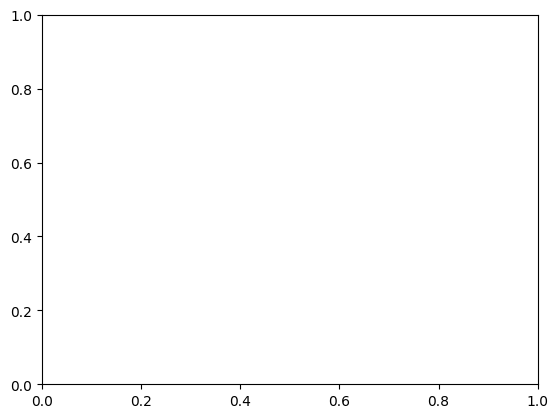

In [14]:
plot_spectrogram(spectrogram)

In [4]:
output.to(torch.float32).div(torch.max(torch.abs(output))).clamp(-1, 1).mul(32767).to(torch.int16).cpu()

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.int16)

In [8]:
!pip install torchvision==0.22 torch==2.7.0 torchaudio==2.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 MB 7.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.8 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0
    Uninstalling torch-2.10.0:
      Successfully uninstalled torch-2.10.0━━━━━ 0/3 [torch]
  Attempting uninstall: torchvision━━━━━━━━━━━━━ 0/3 [torch]
    Found existing installation: torchvision 0.25.032m0/3 [torch]
    Uninstalling torchvision-0.25.0:━━━━━━━━ 0/3 [torch]
      Successfully uninstalled torchvision-0.25.00/3 [torch]
  Attempting uninstall: torchaudiom━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torchvision]
    Found existing installation: torchaudio 2.10.0━━━━━━━━━━━━ 1/3 [torchvision]
    Uninstalling torchaudio-2.10.0:m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torchvision]
      Successfully uninstalled torchaudio-2.10.0━━━━━━━━━━━━━━ 1/3 [torchvision]
   ━━━━━━━━━━━

In [3]:
!pip install torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 4.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
!pip install -U diffusers

In [25]:
import torch
import soundfile as sf
from diffusers import StableAudioPipeline

pipe = StableAudioPipeline.from_pretrained("stabilityai/stable-audio-open-1.0", torch_dtype=torch.float16)
pipe = pipe.to("mps")

# define the prompts
prompt = "The sound of a hammer hitting a wooden surface."
negative_prompt = "Low quality."

# set the seed for generator
generator = torch.Generator("mps").manual_seed(0)

# run the generation
audio = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=200,
    audio_end_in_s=10.0,
    num_waveforms_per_prompt=3,
    generator=generator,
).audios

output = audio[0].T.float().cpu().numpy()
sf.write("hammer.wav", output, pipe.vae.sampling_rate)

Fetching 15 files:  80%|████████  | 12/15 [01:13<00:18,  6.13s/it]


KeyboardInterrupt: 